#**Introdução a DataScience com Python**




## **Análise do dataset do Titanic**

###Upload do arquivo

In [1]:
# Importando o submódulo files da biblioteca google.colab
from google.colab import files

files.upload()

Saving train.csv to train.csv


{'train.csv': b'PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked\r\n1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.25,,S\r\n2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38,1,0,PC 17599,71.2833,C85,C\r\n3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.925,,S\r\n4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1,C123,S\r\n5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.05,,S\r\n6,0,3,"Moran, Mr. James",male,,0,0,330877,8.4583,,Q\r\n7,0,1,"McCarthy, Mr. Timothy J",male,54,0,0,17463,51.8625,E46,S\r\n8,0,3,"Palsson, Master. Gosta Leonard",male,2,3,1,349909,21.075,,S\r\n9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27,0,2,347742,11.1333,,S\r\n10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14,1,0,237736,30.0708,,C\r\n11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4,1,1,PP 9549,16.7,G6,S\r\n12,1,1,"Bonnell, Miss. Elizabeth",female,58,0,0,113783,26.55,C103,S\r\

###Importação das bibliotecas:

In [2]:
import pandas as pd #pandas é muito utilizada para manipulação de dados
import matplotlib.pyplot as plt # Biblioteca para criação de gráficos básicos e personalizados
import seaborn as sns # Biblioteca baseada no matplotlib, usada para criar gráficos estatísticos mais bonitos e informativos

###Primeiras impressões:

In [3]:
# Carregando o dataset do Titanic utilziando a biblioteca Pandas (pd)
df = pd.read_csv("train.csv")

# Visualizando as primeiras linhas para ter uma ideia dos dados
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [4]:
# Verificando informações básicas do DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Análise e Limpeza:

Lidando com Dados Ausentes:

In [5]:
# Verificar a quantidade de valores nulos
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


A coluna "Age" possui mais valores preenchidos do que ausentes. Por isso, eliminar a coluna inteira não é uma estratégia adequada. Em vez disso, preencher os valores nulos utilizando a média (ou mediana) das idades, garantindo que a informação seja preservada de forma consistente. Isso torna-se uma prática mais interessante.

In [6]:
media_idade = df["Age"].median()
df["Age"] = df["Age"].fillna(media_idade)

print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


Como os dados de 'Cabin' acabam sendo irrelevantes para esta análise, não há problemas em remover esta coluna.

IMPORTANTE:

axis=0 (eixo 0): Representa as linhas (índice do DataFrame). A operação será aplicada ao longo das linhas.

axis=1 (eixo 1): Representa as colunas. A operação será aplicada ao longo das colunas.

In [7]:
df.drop("Cabin", axis=1, inplace=True)


DataFrame após a exclusão da coluna Cabin:

In [8]:
print(df.isnull().sum())
print(df.info())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB
None


A coluna "Embarked" contêm poucas linhas com valores nulos. Assim, pode-se preencher os valores nulos com o valor mais comum (a moda da coluna).

In [9]:
moda_embarque = df["Embarked"].mode()[0]
df["Embarked"] = df["Embarked"].fillna(moda_embarque)

print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


## **Análise Exploratória dos Dados**

### Taxa de sobrevivência geral


A coluna "Survived" apresenta valor 0 para "não sobreviveu" e 1 para "sobreviveu".

IMPORTANTE:

Ao adicionar normalize=True, na função value_counts, o Pandas faz a contagem, mas depois divide o resultado pelo total de linhas (passageiros, neste caso). O resultado será um valor entre 0 e 1, que representa a proporção de cada categoria. Multiplicamos o valor por 100 para termos a porcentagem.

In [10]:
sobrevivencia_geral = df["Survived"].value_counts(normalize=True) * 100
print(sobrevivencia_geral)

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


###Análise por Gênero

In [11]:
sobrevivencia_genero = df.groupby("Sex")["Survived"].mean() * 100
print(sobrevivencia_genero)

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


Podemos utilizar a função replace para transformar os valores da coluna: substituindo 0 por "não" e 1 por "sim", facilitando a interpretação dos dados.

In [12]:
df['Survived'] = df['Survived'].replace({0: 'não',1: 'sim'})
display(df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,não,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,sim,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,sim,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,sim,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,não,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


### Análise por Classe (Pclass)

In [13]:
df['Survived'] = (df['Survived'].astype(str).replace({'não': 0, 'sim': 1}).astype(int))
sobrevivencia_classe = df.groupby("Pclass")["Survived"].mean() * 100
print(sobrevivencia_classe)

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


/tmp/ipython-input-1573628949.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Survived'] = (df['Survived'].astype(str).replace({'não': 0, 'sim': 1}).astype(int))


### Análise da taxa de sobrevivência por faixa etária

In [14]:
# Definindo os limites de cada faixa etária
bins = [0,12,18,35,60,100]

# Definindo os rótulos para cada faixa
labels = ["Criança","Adolescente", "Jovem Adulto", "Adulto", "Idoso"]

# Criando a nova coluna "Age-Group"
df["Age_Group"] = pd.cut(df["Age"], bins=bins, labels=labels, right=False) # right=False: Isso garante que o limite superior não seja incluído no intervalo. Por exemplo, a primeira faixa vai de 0 até 11.99 anos.

# Visualizando as primeiras linhas com a nova coluna
#print(df.head())
print(df[["Age", "Age_Group","Survived"]].head())

    Age     Age_Group  Survived
0  22.0  Jovem Adulto         0
1  38.0        Adulto         1
2  26.0  Jovem Adulto         1
3  35.0        Adulto         1
4  35.0        Adulto         0


In [15]:
# Calculando a média de sobrevivência (0 = nao, 1 = sim) para cada grupo
sobrevivencia_por_idade = df.groupby("Age_Group", observed=True)["Survived"].mean() * 100
print(sobrevivencia_por_idade)

Age_Group
Criança         57.352941
Adolescente     48.888889
Jovem Adulto    34.438306
Adulto          41.626794
Idoso           26.923077
Name: Survived, dtype: float64


### Análise da coluna "Fare" (Tarifa)

In [22]:
# Descrição estatística para a coluna "Fare"
print(df["Fare"].describe())

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64


## **Visualização de Dados**

**Sobrevivência por gênero - Gráfico de colunas**

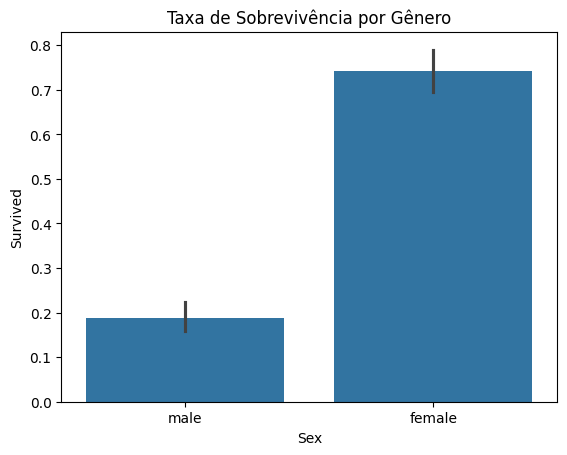

In [17]:
sns.barplot(x='Sex', y='Survived', data=df)
plt.title('Taxa de Sobrevivência por Gênero')
plt.show()

**Sobrevivência por Classe e Gênero (combinado)**

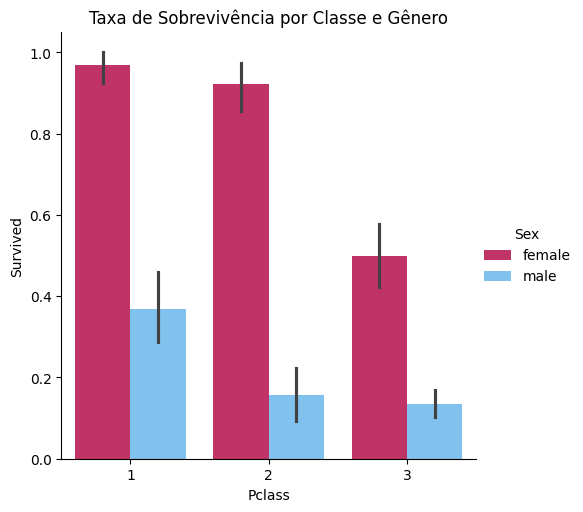

In [18]:
sns.catplot(x='Pclass', y='Survived', hue='Sex', kind='bar', data=df, palette={'male': '#6EC6FF', 'female': '#D81B60' })
plt.title('Taxa de Sobrevivência por Classe e Gênero')
plt.show()

**Sobrevivência por Faixa Etária**

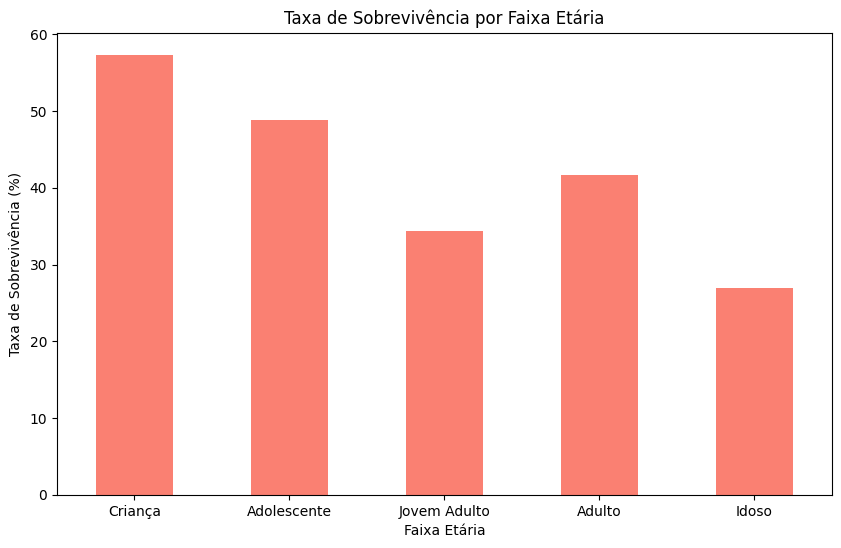

In [19]:
plt.figure(figsize=(10, 6))
sobrevivencia_por_idade.plot(kind='bar', color='salmon')
plt.title('Taxa de Sobrevivência por Faixa Etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Taxa de Sobrevivência (%)')
plt.xticks(rotation=0)
plt.show()

**Visualizando a Distribuição de "Fare" (tarifa)**

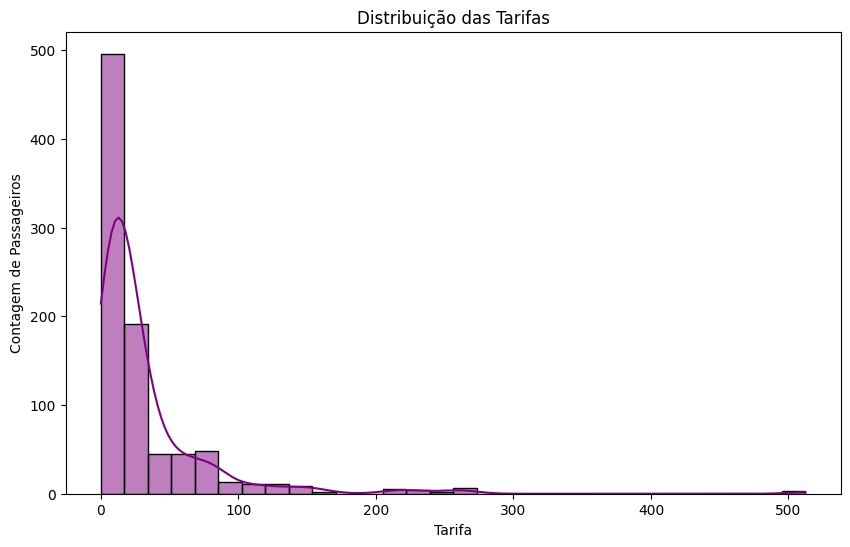

In [20]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Fare'], kde=True, bins=30, color='purple')
plt.title('Distribuição das Tarifas')
plt.xlabel('Tarifa')
plt.ylabel('Contagem de Passageiros')
plt.show()

**Sobrevivência x Tarifa - Gráfico Violino**

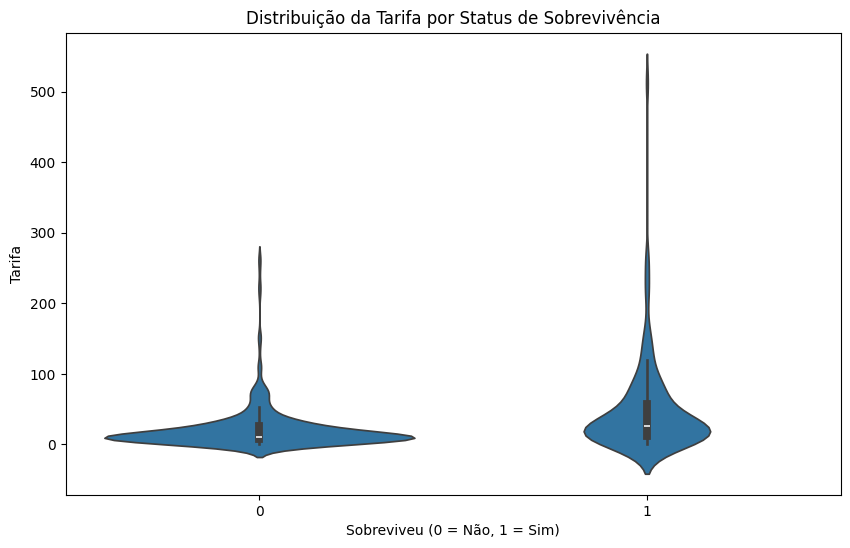

In [21]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='Survived', y='Fare', data=df)
plt.title('Distribuição da Tarifa por Status de Sobrevivência')
plt.xlabel('Sobreviveu (0 = Não, 1 = Sim)')
plt.ylabel('Tarifa')
plt.show()